In [2]:
import pandas as pd
df = pd.read_csv("data/new_cleaned_retail_data_with_churn.csv")
df.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,total_amount,year,month,day,day_of_week,Recency,Churn
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,1,Tuesday,314,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,Tuesday,314,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,1,Tuesday,314,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,1,Tuesday,314,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,1,Tuesday,314,1


In [3]:
customer_summary = df.groupby('customer_id').agg(
    Frequency=('invoice', 'nunique'),
    Monetary=('total_amount', 'sum')
).reset_index()

customer_summary.head()

,customer_id,Frequency,Monetary
0,12346,11,372.86
1,12347,2,1323.32
2,12348,1,222.16
3,12349,3,2671.14
4,12351,1,300.93


In [4]:
rfm = df.groupby('customer_id').agg(
    Recency=('Recency', 'min'),
    Frequency=('invoice', 'nunique'),
    Monetary=('total_amount', 'sum'),
    Churn=('Churn', 'max')
).reset_index()

rfm.head()

,customer_id,Recency,Frequency,Monetary,Churn
0,12346,164,11,372.86,1
1,12347,2,2,1323.32,0
2,12348,73,1,222.16,0
3,12349,42,3,2671.14,0
4,12351,10,1,300.93,0


In [5]:
rfm['Churn'].value_counts()

Churn
0    2885
1    1427
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split

X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((3449, 3), (863, 3))

In [7]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=2,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       577
           1       1.00      1.00      1.00       286

    accuracy                           1.00       863
   macro avg       1.00      1.00      1.00       863
weighted avg       1.00      1.00      1.00       863


Confusion Matrix:
 [[577   0]
 [  0 286]]


In [8]:
import pandas as pd
print(rfm.groupby('Churn')['Recency'].describe())

        count        mean        std   min    25%    50%    75%    max
Churn                                                                 
0      2885.0   32.116118  24.648261   0.0   11.0   27.0   52.0   90.0
1      1427.0  207.544499  80.804831  91.0  136.0  199.0  266.0  373.0


In [9]:
import pandas as pd
importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

Recency      1.0
Frequency    0.0
Monetary     0.0
dtype: float32


In [10]:
X2 = rfm[['Frequency', 'Monetary']]
y2 = rfm['Churn']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

model2 = XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    scale_pos_weight=2, random_state=42, eval_metric='logloss'
)
model2.fit(X2_train, y2_train)
y2_pred = model2.predict(X2_test)

print("Accuracy without Recency:", accuracy_score(y2_test, y2_pred))
print(classification_report(y2_test, y2_pred))

Accuracy without Recency: 0.6593279258400927
              precision    recall  f1-score   support

           0       0.79      0.66      0.72       577
           1       0.49      0.65      0.56       286

    accuracy                           0.66       863
   macro avg       0.64      0.66      0.64       863
weighted avg       0.69      0.66      0.67       863



In [11]:
# Average order value = how much they spend per invoice on average
rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']

# Add a couple more useful signals from the raw transaction data
extra = df.groupby('customer_id').agg(
    TotalQuantity=('quantity', 'sum'),
    UniqueProducts=('stockcode', 'nunique')
).reset_index()

rfm = rfm.merge(extra, on='customer_id', how='left')

rfm.head()

,customer_id,Recency,Frequency,Monetary,Churn,AvgOrderValue,TotalQuantity,UniqueProducts
0,12346,164,11,372.86,1,33.896364,70,26
1,12347,2,2,1323.32,0,661.660000,828,70
2,12348,73,1,222.16,0,222.160000,373,20
3,12349,42,3,2671.14,0,890.380000,993,90
4,12351,10,1,300.93,0,300.930000,261,21


In [12]:
X3 = rfm[['Frequency', 'Monetary', 'AvgOrderValue', 'TotalQuantity', 'UniqueProducts']]
y3 = rfm['Churn']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

model3 = XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    scale_pos_weight=2, random_state=42, eval_metric='logloss'
)
model3.fit(X3_train, y3_train)
y3_pred = model3.predict(X3_test)

print("Accuracy:", accuracy_score(y3_test, y3_pred))
print(classification_report(y3_test, y3_pred))

importance3 = pd.Series(model3.feature_importances_, index=X3.columns)
print("\nFeature Importance:\n", importance3.sort_values(ascending=False))

Accuracy: 0.6720741599073001
              precision    recall  f1-score   support

           0       0.83      0.64      0.72       577
           1       0.50      0.73      0.60       286

    accuracy                           0.67       863
   macro avg       0.67      0.69      0.66       863
weighted avg       0.72      0.67      0.68       863


Feature Importance:
 Frequency         0.649970
UniqueProducts    0.123811
Monetary          0.084922
AvgOrderValue     0.070765
TotalQuantity     0.070532
dtype: float32


In [13]:
from sklearn.metrics import roc_auc_score

y3_proba = model3.predict_proba(X3_test)[:, 1]
auc = roc_auc_score(y3_test, y3_proba)
print("AUC-ROC:", auc)

AUC-ROC: 0.742725212395923


In [14]:
!pip install lightgbm


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from lightgbm import LGBMClassifier

model_lgb = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=2,
    random_state=42
)
model_lgb.fit(X3_train, y3_train)

y_lgb_proba = model_lgb.predict_proba(X3_test)[:, 1]
y_lgb_pred = model_lgb.predict(X3_test)

print("LightGBM AUC-ROC:", roc_auc_score(y3_test, y_lgb_proba))
print(classification_report(y3_test, y_lgb_pred))

[LightGBM] [Info] Number of positive: 1141, number of negative: 2308
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000189 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1060
[LightGBM] [Info] Number of data points in the train set: 3449, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.330821 -> initscore=-0.704476
[LightGBM] [Info] Start training from score -0.704476
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [16]:
customer_dates = df.groupby('customer_id')['invoicedate'].agg(['min', 'max']).reset_index()
customer_dates.columns = ['customer_id', 'first_purchase', 'last_purchase']

customer_dates['first_purchase'] = pd.to_datetime(customer_dates['first_purchase'])
customer_dates['last_purchase'] = pd.to_datetime(customer_dates['last_purchase'])

customer_dates['Tenure'] = (customer_dates['last_purchase'] - customer_dates['first_purchase']).dt.days

rfm = rfm.merge(customer_dates[['customer_id', 'Tenure']], on='customer_id', how='left')

rfm['AvgDaysBetweenPurchases'] = rfm['Tenure'] / rfm['Frequency']

rfm.head()

,customer_id,Recency,Frequency,Monetary,Churn,AvgOrderValue,TotalQuantity,UniqueProducts,Tenure,AvgDaysBetweenPurchases
0,12346,164,11,372.86,1,33.896364,70,26,196,17.818182
1,12347,2,2,1323.32,0,661.660000,828,70,37,18.500000
2,12348,73,1,222.16,0,222.160000,373,20,0,0.000000
3,12349,42,3,2671.14,0,890.380000,993,90,181,60.333333
4,12351,10,1,300.93,0,300.930000,261,21,0,0.000000


In [17]:
X4 = rfm[['Frequency', 'Monetary', 'AvgOrderValue', 'TotalQuantity', 'UniqueProducts', 'Tenure', 'AvgDaysBetweenPurchases']]
y4 = rfm['Churn']

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y4, test_size=0.2, random_state=42, stratify=y4
)

model4 = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=2, random_state=42, eval_metric='logloss'
)
model4.fit(X4_train, y4_train)

y4_proba = model4.predict_proba(X4_test)[:, 1]
y4_pred = model4.predict(X4_test)

print("AUC-ROC:", roc_auc_score(y4_test, y4_proba))
print(classification_report(y4_test, y4_pred))

importance4 = pd.Series(model4.feature_importances_, index=X4.columns)
print("\nFeature Importance:\n", importance4.sort_values(ascending=False))

AUC-ROC: 0.7831137666492951
              precision    recall  f1-score   support

           0       0.87      0.64      0.74       577
           1       0.53      0.80      0.64       286

    accuracy                           0.70       863
   macro avg       0.70      0.72      0.69       863
weighted avg       0.75      0.70      0.70       863


Feature Importance:
 Tenure                     0.624589
UniqueProducts             0.093724
AvgDaysBetweenPurchases    0.087491
TotalQuantity              0.061021
AvgOrderValue              0.052844
Monetary                   0.048132
Frequency                  0.032199
dtype: float32


In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.1]
}

grid_search = GridSearchCV(
    XGBClassifier(scale_pos_weight=2, random_state=42, eval_metric='logloss'),
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)
grid_search.fit(X4_train, y4_train)

print("Best params:", grid_search.best_params_)
print("Best CV AUC:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_best_proba = best_model.predict_proba(X4_test)[:, 1]
print("Test AUC-ROC:", roc_auc_score(y4_test, y_best_proba))

Best params: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100}
Best CV AUC: 0.7945705410937179
Test AUC-ROC: 0.7828441056344003


In [19]:
!pip install shap


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
!pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


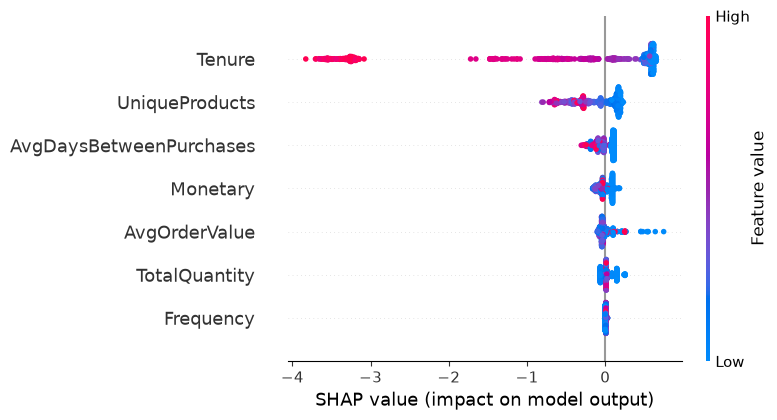

In [21]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X4_test)

shap.summary_plot(shap_values, X4_test)

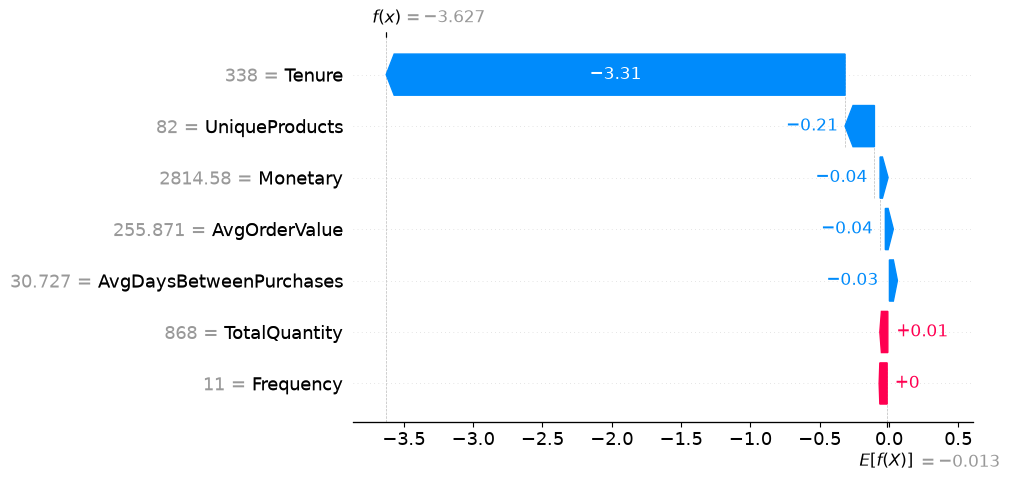

In [22]:
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X4_test.iloc[0],
    feature_names=X4_test.columns.tolist()
))

In [23]:
import joblib

joblib.dump(best_model, 'churn_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [25]:
import os
import joblib

# Create folders if they don't exist
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)

# Save churn model
joblib.dump(best_model, 'models/churn_model.pkl')

# Save prophet model
joblib.dump(prophet_model, 'models/prophet_model.pkl')

# Save segmentation model
joblib.dump(kmeans, 'models/segmentation_model.pkl')

# Save scaler
joblib.dump(scaler, 'models/scaler.pkl')

# Save customer segments CSV
rfm.to_csv('data/customer_segments.csv', index=False)

print("All models saved successfully!")
print("Files in models folder:")
for f in os.listdir('models'):
    print(" -", f)

NameError: name 'prophet_model' is not defined

In [26]:
import os
# Check what files exist right now
print("Current folder contents:")
for f in os.listdir('.'):
    print(" -", f)

Current folder contents:
 - .git
 - .gitignore
 - .ipynb_checkpoints
 - append_explanation.py
 - churn_model.pkl
 - churn_prediction-checkpoint.ipynb
 - churn_prediction.ipynb
 - Cleaning.py
 - Code_Explanation.md
 - create_notebook.py
 - create_segmentation_notebook.py
 - customer_segmentation.ipynb
 - data
 - demand_forecasting.ipynb
 - fix_notebook.py
 - fix_path.py
 - inference.py
 - lightning_logs
 - mlflow.db
 - models
 - README.md


In [27]:
import os

print("Models folder contents:")
for f in os.listdir('models'):
    print(" -", f)

print("\nData folder contents:")
for f in os.listdir('data'):
    print(" -", f)

Models folder contents:
 - churn_model.pkl

Data folder contents:
 - new_cleaned_retail_data_with_churn.csv
